In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
import sigmaX_fidelity_optimize as zpX
from brokenaxes import brokenaxes
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import plotly.graph_objects as go
import plotly.io as pio
import scipy as sp
from joblib import Parallel, delayed

In [2]:
truc1 = 300
drive_phi = False
drive_theta = True

EL   = 0.04 # GHz
EJ   = 10 # Soft Zero Pi (Gyenis)
E_CJ = 20
E_C  = 0.04

# EL        = 0.377 # GHz
# EJ        = 6.013 # Soft Zero Pi (Gyenis)
# EC_phi    = 1.142
# EC_theta  = 0.092
# E_CJ = 2 * EC_phi
# E_C = 2./(1./EC_theta -1./EC_phi)

phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 100)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=30, truncated_dim=truc1)
n_Theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc1)
n_Phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc1)
n_phi = 2*np.pi * qt.Qobj(n_Phi)
n_theta = 2*np.pi * qt.Qobj(n_Theta)

evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc1)
H0 = qt.Qobj(np.diag(evals))

if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_theta
if drive_phi and drive_theta:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = 0.976*n_phi+ 0.024*n_theta

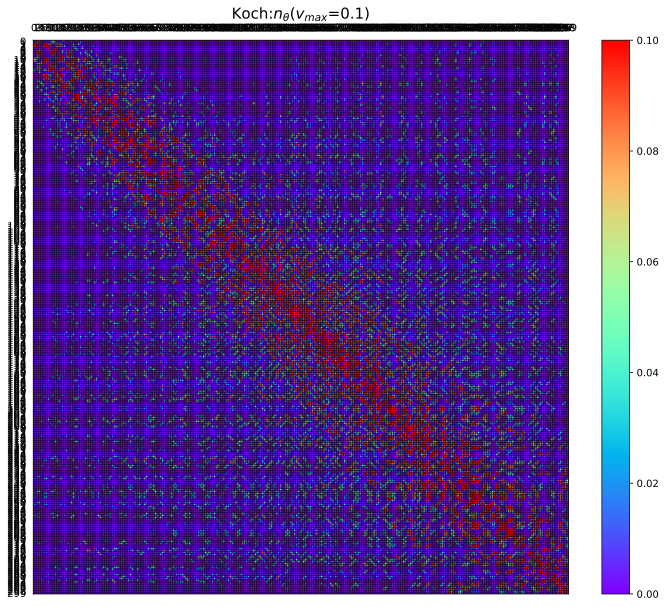

In [3]:
vmax = 0.1
truc2 = 300
fig, ax = plt.subplots(figsize=(12,10))
font_size = 15
plt.imshow(np.abs(n_Theta[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title('Koch:$n_{\\theta}$($v_{max}$='+f'{vmax})' , pad=5,fontsize=font_size)
ax.set_xticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1))
ax.set_yticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1))
# ax.set_yticks(np.arange(0, dim_plot, 1),["|0>","|1>","|2>","|3>","|4>","|5>","|6>","|7>","|8>","|9>"])
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

#### only consider leakage directly from logical states

In [4]:
thresh= 1e-0
hspace_comp = [0,1]
hspace_direct = hspace_comp
for i in hspace_comp:
    for j in range(truc2):
        if np.abs(n_Theta[i,j]) > thresh:
            hspace_direct.append(j)
print('threshold=', thresh)
print('num of truncation (direct) =', len(hspace_direct))
print('hilbert_space :')
dim = 10
data = hspace_direct
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

KeyboardInterrupt: 

#### consider leakage directly and indirectly from logical states

threshold= [1e-8,0.1]
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,

In [ ]:
logi_index

[0, 3, 5, 21]

In [ ]:
# logi_index = [order_sort.index(x) for x in logi_space]
threshold = 1e-1
hspace_charge = [0, 3, 5, 21]
for i in hspace_charge:
    for j in range(n_theta1_dress.shape[0]):
        if np.abs(n_theta2_dress[i,j]) > threshold and j not in hspace_charge:
            hspace_charge.append(j)
print('threshold=', threshold)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.1
num of truncation = 49
hilbert_space :
0, 3, 5, 21, 1, 2, 10, 16, 20, 12 ,
14, 40, 45, 55, 7, 8, 9, 28, 32, 36 ,
44, 29, 31, 35, 67, 74, 69, 81, 25, 26 ,
27, 57, 60, 64, 71, 76, 58, 62, 90, 93 ,
97, 98, 49, 52, 83, 87, 85, 94, 99 ,


In [ ]:
# truc = 300
# drive_phi = True
# drive_theta = False
# [H0, drive_term, w_trans_1, w_trans_2] = ut.zero_pi_intialize(drive_phi, drive_theta, truncation=truc)

#### Find truncation from charge matrix element

In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:

            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 161
hilbert_space :
0, 1, 2, 3, 6, 7, 9, 10, 11, 13 ,
15, 16, 17, 19, 21, 22, 25, 26, 28, 29 ,
32, 33, 36, 37, 40, 42, 43, 48, 49, 50 ,
51, 52, 56, 57, 59, 60, 61, 62, 63, 68 ,
69, 71, 72, 74, 75, 77, 81, 84, 85, 87 ,
88, 89, 90, 96, 97, 98, 99, 101, 104, 105 ,
106, 110, 111, 112, 113, 117, 118, 119, 120, 124 ,
125, 128, 129, 132, 133, 136, 137, 139, 140, 144 ,
145, 147, 148, 151, 152, 156, 157, 159, 160, 161 ,
163, 166, 167, 169, 170, 174, 175, 176, 179, 180 ,
181, 182, 187, 188, 189, 192, 193, 198, 199, 200 ,
201, 202, 207, 208, 212, 213, 215, 216, 220, 221 ,
226, 227, 228, 229, 232, 233, 236, 237, 238, 239 ,
244, 245, 246, 247, 248, 249, 250, 251, 256, 257 ,
258, 261, 262, 263, 264, 269, 270, 271, 272, 273 ,
274, 277, 278, 281, 282, 290, 291, 294, 295, 298 ,
299 ,


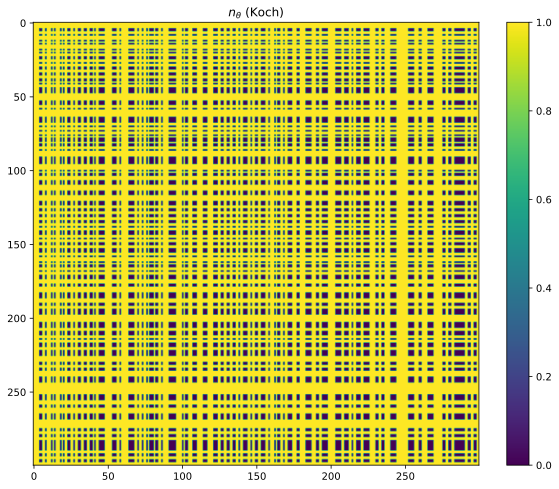

In [39]:
matrix = np.zeros((truc, truc))
matrix[hspace_charge, :] = 1  # 设置指定行
matrix[:, hspace_charge] = 1  # 设置指定列

fig, ax = plt.subplots(figsize=(10, 8))
plt.imshow(matrix, cmap='viridis', aspect='auto')
plt.title(r'$n_\theta$ (Koch)')
plt.colorbar()
plt.show()


In [ ]:
thresh = 0.0001
hspace_charge = [0, 2]
for s in hspace_charge:
    for i in range(truc):
        if np.abs(drive_term[s, i]/(2*np.pi)) > thresh and i not in hspace_charge:
            hspace_charge.append(i)
hspace_charge.sort()
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta)
print('nphi threshold=', thresh)
print('num of truncation =', len(hspace_charge))
print('hilbert_space :')
dim = 10
data = hspace_charge
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')


drive_phi= False ; drive_theta =  True
nphi threshold= 0.0001
num of truncation = 29
hilbert_space :
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48 ,


### drive $n_\theta$ - get fidelity for 100 levels

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [22, 0.21142888, 0.04991373, 0.002936, -0.00242995]
truc1=50
hilbert_space = np.arange(truc1)
arg = [drive_amp_A, drive_amp_B, detune_A, detune_B]
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hilbert_space)
f_300 = ut.xgate_fidelity_optimize(arg, *args)
f_300

-1.1384548235470549

### drive $n_\theta$ - get fidelity by removing a level (parallel)

1. truc=50    lg(1-F)=-1.6015
2. truc=100 lg(1-F)=-1.2961

In [6]:
args = (H0, drive_term, tg, w_trans_1, w_trans_2, hspace_charge)
f_157 = ut.xgate_fidelity_optimize(arg, *args)
f_157

-1.138542318012815

In [7]:
print(1- 10**f_300)
print(1- 10**f_157)

0.9272981978394608
0.9273128431202388


In [18]:
hspace = np.arange(truc1)
args = [H0, drive_term, w_trans_1, w_trans_2, hspace]
f_theta = Parallel(n_jobs=len(param_theta), verbose=1)(delayed(ut.xgate_fidelity_arg5)(arg, args)
                                            for arg in para_tot)

print('\nfidelity = ')
dim = 5
data = f_theta
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:  1.1min remaining:  8.0min



fidelity = 
-1.291915, -0.912229, -1.662145, -1.478222, -1.175574 ,
-1.569847, -0.7981, -2.113408, -1.426514, -2.26666 ,
-2.140774, -0.872873, -2.582661, -2.208428, -2.356036 ,
-2.694133 ,


[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:  3.8min finished


In [ ]:
=

In [ ]:
level_start = np.arange(0, truc1, step=1)
levels = np.arange(3, truc1, step=1)
hspace_grid = []
for level in levels:
    hspace_grid.append(np.delete(level_start, level))

f_theta = Parallel(n_jobs=len(levels), verbose=1)(delayed(ut.get_fidelity_given_hspace)(hspace, argz)
                                            for hspace in hspace_grid)
# print('\nfidelity = ')
# dim = 5
# data = f_theta
# for i in range(0, len(data), dim):
#     print(', '.join(map(str, np.round(data[i:i+dim], 6) )), ',')

####  drive $n_\theta$ - get fidelity given levels

In [ ]:
f_theta = [
    -1.29606479, -0.23390096, -0.20476632, -1.29606491 ,
    -0.17794121, -0.39072164, -1.29606474, -1.29606504 ,
    -0.25686453, -0.78325307, -1.29606545, -1.29606489 ,
    -1.29606532, -1.21461004, -1.16453124, -0.34342454 ,
    -1.29606494, -1.29606572, -1.25056463, -1.29606549 ,
    -1.27048983, -1.2960659, -0.27666921, -1.29606546 ,
    -0.8518462, -1.29606648, -1.29606641, -1.26151253 ,
    -1.23555753, -1.35343648, -1.32242524, -1.2960678 ,
    -1.29606765, -1.29606844, -1.2160092, -0.91022508 ,
    -1.29606873, -1.46763772, -1.3565264, -1.22692592 ,
    -1.29606768, -1.29606949, -1.07256834, -1.35222928 ,
    -1.30550213, -1.06191345, -1.29606506, -1.29606506 ,
    -1.2604177, -1.2791995, -1.29606396, -1.29606262 ,
    -1.29606132, -1.29710799, -1.2960652, -1.29606548 ,
    -1.40267125, -1.2960673, -1.29606636, -1.23016757 ,
    -1.25546211, -1.28399308, -1.28950719, -1.29606756 ,
    -1.29688577, -1.29606185, -1.29605482, -1.29606973 ,
    -1.29606953, -1.45108441, -1.4510346, -1.38057674 ,
    -1.29606459, -1.31629272, -1.29605089, -1.2971586 ,
    -1.28798824, -1.29596135, -1.29605682, -1.29263129 ,
    -1.28502376, -1.29607003, -1.29521176, -1.29605065 ,
    -1.18889455, -1.19505596, -1.29606712, -1.30140701 ,
    -1.29606483, -1.32068015, -1.31851872, -1.29607053 ,
    -1.29607052, -1.30625864, -1.30182707, -1.30069849 ,
    -1.29606547 ,
 ]
level_start = np.arange(0, truc1, step=1)
levels = np.arange(3, truc1, step=1)
hspace = [0, 1, 2]
f_100 = -1.2960641216930395
for level, f in zip(levels, f_theta):
    if np.abs(f - np.round(f_100, 6)) >= 0.00001:
        hspace.append(level)
f_truc = ut.get_fidelity_given_hspace(hspace, argz)
print('fidelity =', f_truc)
print('num of truncation =', len(hspace))
dim = 10
data = hspace
for i in range(0, len(data), dim):
    print(', '.join(map(str, np.round(data[i:i+dim], 8) )), ',')
# len(hspace) = 58
# hspace_charge = [
# 0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
# 17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
# 37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
# 52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
# 74, 76, 77, 78, 79, 80, 82, 83, 85, 86 ,
# 87, 88, 90, 92, 93, 96, 97, 98 ,
#     ]
print('Difference to the 100 levels:', np.round(10**(f_100) - 10**(f_truc), 8))

fidelity = -1.2960372768639832
num of truncation = 58
0, 1, 2, 4, 5, 7, 8, 11, 12, 16 ,
17, 18, 21, 23, 25, 27, 30, 31, 32, 33 ,
37, 38, 40, 41, 42, 45, 46, 47, 48, 51 ,
52, 56, 59, 62, 63, 64, 65, 67, 72, 73 ,
74, 76, 77, 78, 79, 80, 82, 83, 85, 86 ,
87, 88, 90, 92, 93, 96, 97, 98 ,
Difference to the 100 levels: -3.13e-06


In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

####  drive $n_\theta$ - get fidelity by sweeping truncation

In [ ]:
# truc_vec = np.arange(150,250, 50)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.239886, 0.0551455, -0.0051449, -0.00191928] # truc=50
fidel = []
for truc in tqdm([truc]):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_Theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_Phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_phi = 2*np.pi * qt.Qobj(n_Phi)
    n_theta = 2*np.pi * qt.Qobj(n_Theta)
    states = [qt.basis(truc, i) for i in range(truc)]

    H_qbt_drive = [H0,  [n_theta, ut.drive_gauss_A],
                        [n_theta, ut.drive_gauss_B],]
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
fidel = np.array(fidel)
# print('truncation = ', truc_vec.tolist())
print('fidelity = ', np.round(fidel.tolist(), 4))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [01:08<00:00, 68.98s/it]

fidelity =  [-1.2961]


In [ ]:
# truc_vec = np.arange(150,250, 50)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.239886, 0.0551455, -0.0051449, -0.00191928] # truc=50
fidel = []
for truc in tqdm([truc]):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_Theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_Phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_phi = 2*np.pi * qt.Qobj(n_Phi)
    n_theta = 2*np.pi * qt.Qobj(n_Theta)
    states = [qt.basis(truc, i) for i in range(truc)]

    H_qbt_drive = [H0,  [n_theta, ut.drive_gauss_A],
                        [n_theta, ut.drive_gauss_B],]
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
fidel = np.array(fidel)
# print('truncation = ', truc_vec.tolist())
print('fidelity = ', np.round(fidel.tolist(), 4))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [01:26<00:00, 86.39s/it]

fidelity =  [-1.2961]


In [ ]:
=

### drive $n_\phi+n_\theta$

In [ ]:
truc_vec = np.array([10]) # np.arange(40,100, 10)
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [20, 0.09871602296401119, 0.20900225470826742, 0.22214075955138304, 0.22595164441346902]
# [100, 0.14515, 0.12585, -0.09084, -0.068318] # truc=50

fidel = []
for truc in tqdm(truc_vec):
    zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=dEJ,
                            ng=ng, flux=0., ncut=30, truncated_dim=truc)
    n_Theta = zero_pi.matrixelement_table(operator='n_theta_operator', evals_count=truc)
    n_Phi = zero_pi.matrixelement_table(operator='i_d_dphi_operator', evals_count=truc)
    evals = 2*np.pi * zero_pi.eigenvals(evals_count=truc)
    H0 = qt.Qobj(np.diag(evals))
    n_phi = 2*np.pi * qt.Qobj(n_Phi)
    n_theta = 2*np.pi * qt.Qobj(n_Theta)
    states = [qt.basis(truc, i) for i in range(truc)]
    H_qbt_drive = [H0,  [0.976*n_phi+ 0.024*n_theta, ut.drive_gauss_A],
                        [0.976*n_phi+ 0.024*n_theta, ut.drive_gauss_B],]
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
    arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
    fidel.append(ut.get_fidelity_x(arg_de, *args))
    print('log of gate error = ', fidel)
fidel = np.array(fidel)
print('truncation = ', truc_vec.tolist())
print('log of gate error = ', np.round(fidel.tolist(), 2))
# truncation =  [50, 60, 70, 80, 90, 100]
# fidelity =  [-4.02, -3.32, -3.39, -2.07, -2.05, -1.97]

100%|██████████| 1/1 [00:01<00:00,  1.28s/it]

log of gate error =  [-0.17687082013375752]
truncation =  [10]
log of gate error =  [-0.18]


In [ ]:
hilbert_space = [0, 2]
for s in hilbert_space:
    print('s=', s)
    for i in range(truc):
        if np.abs((0.976*n_Phi+ 0.024*n_Theta)[s, i]) > thresh and i not in hilbert_space:
            hilbert_space.append(i)
    print(len(hilbert_space), hilbert_space)

hilbert_space.sort()
print(len(hilbert_space), hilbert_space)

s= 0
16 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81]
s= 2
22 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95]
s= 1
38 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89]
s= 9
61 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 33, 37, 40, 42, 46, 47, 56, 62, 64, 73, 76, 79, 83, 85, 92, 98]
s= 10
64 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 33, 37, 40, 42, 46, 47, 56, 62, 64, 73, 76, 79, 83, 85, 92, 98, 51, 88, 96]
s= 15
65 [0, 2, 1, 9, 10, 15, 20, 24, 28, 35, 53, 55, 57, 66, 69, 81, 5, 19, 39, 43, 91, 95, 4, 6, 13, 14, 22, 26, 34, 36, 44, 50, 54, 58, 61, 75, 80, 89, 8, 11, 16, 18, 23, 25, 31, 

### drive $n_\phi$

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [100,  0.22347715,  0.2959175,  -0.09120307, -0.09866836]
# [20, 0.23727472360716756, 0.05702996586746281, -0.011634756539731306, -0.008421158022791796]
w_trans_1 = evals[9] - evals[0]
w_trans_2 = evals[9] - evals[2]
H_qbt_drive = [H0,  [n_phi, ut.drive_gauss_A],
                    [n_phi, ut.drive_gauss_B],]
args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
fidel = ut.get_fidelity_x(arg_de, *args)
print('fidelity = ', fidel)

capi_return is NULL
Call-back cb_f_in_zvode__user__routines failed.


KeyboardInterrupt: 

In [ ]:
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg }
tlist = np.linspace(0, tg,  num=int(2*tg))  # total time
options = qt.Options(store_states=True)
result = {}
logi_state = [0,2]
for jdx, state_j in enumerate(logi_state):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=options  )

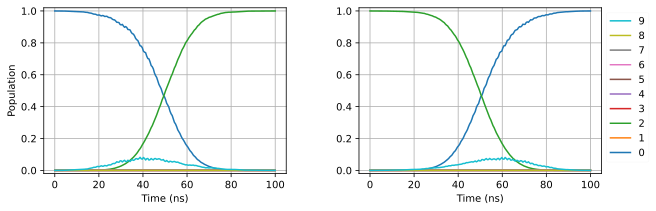

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist, drive)
# fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\omega_d$=%.4f'%trans_freq )
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        ax[jdx].plot(tlist, np.array(res).flatten(), label=r"%d"%state)
    ax[jdx].set_ylim(-0.02,1.02)
    ax[jdx].grid()
    ax[jdx].set_xlabel('Time (ns)')
    # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[1].set_xlabel('Time (ns)')
ax[0].set_ylabel('Population')
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1],labels[::-1],
            loc='upper left',
            bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

### drive $n_\theta$

In [ ]:
tg, drive_amp_A, drive_amp_B, detune_A, detune_B = [60, 0.15042571732968524, 0.04685021908945983, 0.03748943485669252, 0.04001032187908264] # truc=50
# [50, 0.18119098768466624, 0.04852080708313111, -0.29998867553241776, -0.27744829942203275] # truc = 10
H_qbt_drive = [H0,  [n_theta, ut.drive_gauss_A],
                    [n_theta, ut.drive_gauss_B],]
w_trans_1 = evals[7] - evals[0]
w_trans_2 = evals[7] - evals[2]
args = (tg, w_trans_1, w_trans_2, states, H_qbt_drive)
arg_de = (drive_amp_A, drive_amp_B, detune_A, detune_B)
fidel = ut.get_fidelity_x(arg_de, *args)
print('fidelity = ', fidel)


fidelity =  -3.3241345830634925


In [ ]:

pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg }
tlist = np.linspace(0, tg,  num=int(2*tg))  # total time
options = qt.Options(store_states=True)
result = {}
logi_state = [0,2]
for jdx, state_j in enumerate(logi_state):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=options  )

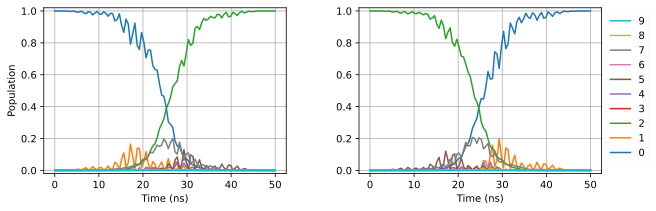

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist, drive)
# fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\omega_d$=%.4f'%trans_freq )
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        ax[jdx].plot(tlist, np.array(res).flatten(), label=r"%d"%state)
    ax[jdx].set_ylim(-0.02,1.02)
    ax[jdx].grid()
    ax[jdx].set_xlabel('Time (ns)')
    # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[1].set_xlabel('Time (ns)')
ax[0].set_ylabel('Population')
handles, labels = ax[1].get_legend_handles_labels()
ax[1].legend(handles[::-1],labels[::-1],
            loc='upper left',
            bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

In [ ]:
=

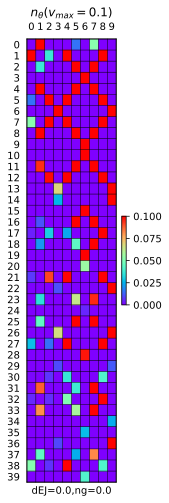

In [ ]:
fig, ax = plt.subplots(figsize=(2,8))
# font_size = 15
truc_x = 10
plt.imshow(np.abs(n_Theta[:,:truc_x]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta}(v_{max}=$'+f'{vmax})' )
plt.xlabel('dEJ='+f'{dEJ}' + ',ng='+f'{ng}' )
ax.set_xticks(np.arange(0, truc_x, 1), np.arange(0, truc_x, 1))
ax.set_yticks(np.arange(0, truc, 1), np.arange(0, truc, 1))
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc_x, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.2)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')

In [ ]:
# tg_vec = [50]
# argss = (w_trans_1, w_trans_2, states, H_qbt_drive)
# zpX.fidelity_de(tg_vec, argss)